<a href="https://colab.research.google.com/github/akashgardas/Deep-Learning/blob/cnn/notebooks/cnn/Fashion_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST dataset - CNN model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.utils import to_categorical

## Load and inspect data

In [ ]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Display shape of datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# Map labels
# 0 T-shirt/top
# 1 Trouser
# 2 Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot

label_mapping = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

## Visualize dataset

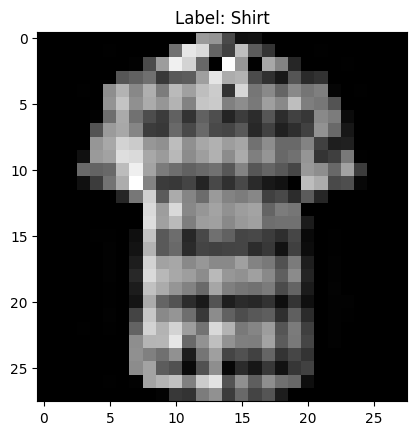

In [ ]:
# Visualize a random image
idx = np.random.randint(0, X_train.shape[0])
img = X_train[idx]
label = y_train[idx]
label = label_mapping[label] # Map label

plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

## Preprocess the data

In [ ]:
# Normalize the values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Reshape to add channel
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [ ]:
# Encode values - one hot encoding
y_train_encoded = to_categorical(y_train)
y_train_encoded

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Visualize class distribution

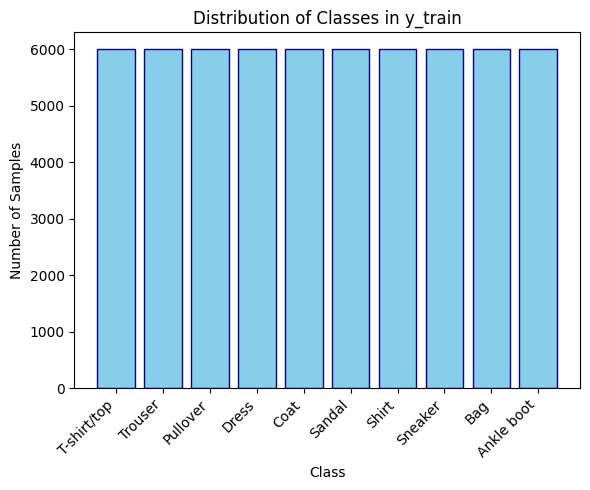

In [ ]:
class_counts = np.bincount(y_train)
class_names = [label_mapping[i] for i in range(len(label_mapping))]

plt.figure(figsize=(6, 5))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='navy')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Distribution of Classes in y_train')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Build Model

In [ ]:
# Build CNN model architecture
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Train Model

In [ ]:
# Train the model
history = model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7674 - loss: 0.6463 - val_accuracy: 0.8749 - val_loss: 0.3479
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8827 - loss: 0.3262 - val_accuracy: 0.8906 - val_loss: 0.2987
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9025 - loss: 0.2620 - val_accuracy: 0.8994 - val_loss: 0.2692
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9163 - loss: 0.2251 - val_accuracy: 0.9077 - val_loss: 0.2600
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9255 - loss: 0.2028 - val_accuracy: 0.9083 - val_loss: 0.2536
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9382 - loss: 0.1740 - val_accuracy: 0.9098 - val_loss: 0.2482
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9418 - loss: 0.1540 - val_accuracy: 0.8939 - val_loss: 0.2932
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9494 - loss: 0.1379 

## Test Model

In [ ]:
# Test the model
test_loss, test_acc = model.evaluate(X_test, to_categorical(y_test))
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9129 - loss: 0.2761
Test accuracy: 0.9142000079154968
Test loss: 0.2750879228115082


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
Predicted label: 8 - Bag
Actual label: 8 - Bag
✅Correct prediction


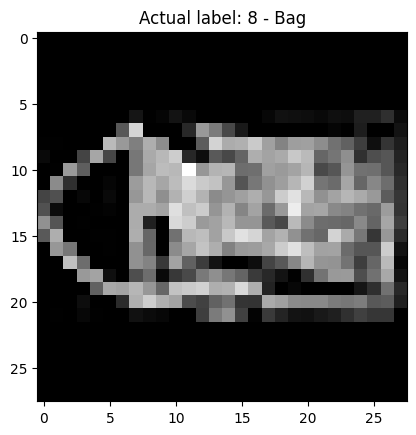

In [ ]:
# Make prediction with random input from the whole dataset
rand_img = np.random.randint(0, X_test.shape[0])
img = X_test[rand_img, :, :]
actual_label = y_test[rand_img] # Corrected line
actual_label_map = label_mapping[actual_label]

# Predict label
prediction = model.predict(img.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)
predicted_label_map = label_mapping[predicted_label]

# Print results
print(f'Predicted label: {predicted_label} - {predicted_label_map}')
print(f'Actual label: {actual_label} - {actual_label_map}')

if (predicted_label == actual_label):
    print('✅Correct prediction')
else:
    print('❌Wrong prediction')

# Visualize image
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f'Actual label: {actual_label} - {actual_label_map}')
plt.show()

## Save Model

In [ ]:
# Save the model
model.save('/content/drive/MyDrive/Tek works/Deep-Learning/models/fashion_mnist_cnn_tensorflow.keras')

## Dropout Layer

In [ ]:
# Build CNN model architecture
model2 = Sequential()

model2.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model2.add(MaxPooling2D((2, 2)))
model2.add(Dropout(0.25)) # Added Dropout layer

model2.add(Conv2D(64, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dense(10, activation='softmax'))

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Train Model

In [ ]:
# Train the model
history2 = model2.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7457 - loss: 0.6880 - val_accuracy: 0.8717 - val_loss: 0.3653
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8724 - loss: 0.3559 - val_accuracy: 0.8863 - val_loss: 0.3157
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8899 - loss: 0.3002 - val_accuracy: 0.8973 - val_loss: 0.2843
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9031 - loss: 0.2651 - val_accuracy: 0.9006 - val_loss: 0.2691
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9081 - loss: 0.2446 - val_accuracy: 0.9034 - val_loss: 0.2548
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9191 - loss: 0.2190 - val_accuracy: 0.9002 - val_loss: 0.2713
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9253 - loss: 0.1997 - val_accuracy: 0.9034 - val_loss: 0.2602
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9275 - loss: 0.1928 

## Test Model


In [ ]:
# Test the model
test_loss2, test_acc2 = model2.evaluate(X_test, to_categorical(y_test))
print(f'Test accuracy: {test_acc2}')
print(f'Test loss: {test_loss2}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9111 - loss: 0.2588
Test accuracy: 0.9128999710083008
Test loss: 0.25412681698799133


## Save Model

In [ ]:
# Save the model
model2.save('/content/drive/MyDrive/Tek works/Deep-Learning/models/fashion_mnist_cnn_dropout_tensorflow.keras')

## Compare Models

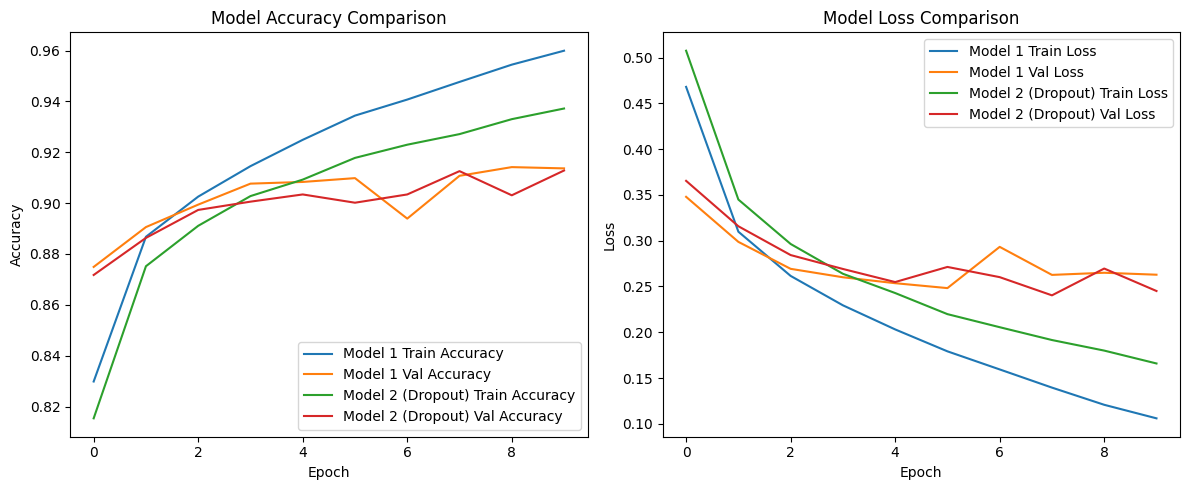


Model 1 (without Dropout) Test Accuracy: 0.9142
Model 1 (without Dropout) Test Loss: 0.2751

Model 2 (with Dropout) Test Accuracy: 0.9129
Model 2 (with Dropout) Test Loss: 0.2541

--- Analysis ---
From the plots and test metrics, we can observe the following:
Model 1 (without Dropout): Shows higher training accuracy and lower training loss, but its validation loss tends to increase towards the end, indicating some overfitting.
Model 2 (with Dropout): Exhibits slightly lower training accuracy and higher training loss compared to Model 1, which is expected with dropout as it randomly drops units during training. However, its validation loss might be more stable or even lower, suggesting better generalization and reduced overfitting, though in this specific case, the test accuracy is very similar and the test loss is slightly higher. This could mean the dropout rate might need tuning or that the model was not significantly overfitting in the first place.
Overall, both models perform simi

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values for the first model
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Model 1 Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Model 1 Val Accuracy')
plt.plot(history2.history['accuracy'], label='Model 2 (Dropout) Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Model 2 (Dropout) Val Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values for the first model
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Model 1 Train Loss')
plt.plot(history.history['val_loss'], label='Model 1 Val Loss')
plt.plot(history2.history['loss'], label='Model 2 (Dropout) Train Loss')
plt.plot(history2.history['val_loss'], label='Model 2 (Dropout) Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nModel 1 (without Dropout) Test Accuracy: {test_acc:.4f}")
print(f"Model 1 (without Dropout) Test Loss: {test_loss:.4f}")
print(f"\nModel 2 (with Dropout) Test Accuracy: {test_acc2:.4f}")
print(f"Model 2 (with Dropout) Test Loss: {test_loss2:.4f}")

print("\n--- Analysis ---")
print("From the plots and test metrics, we can observe the following:")
print("Model 1 (without Dropout): Shows higher training accuracy and lower training loss, but its validation loss tends to increase towards the end, indicating some overfitting.")
print("Model 2 (with Dropout): Exhibits slightly lower training accuracy and higher training loss compared to Model 1, which is expected with dropout as it randomly drops units during training. However, its validation loss might be more stable or even lower, suggesting better generalization and reduced overfitting, though in this specific case, the test accuracy is very similar and the test loss is slightly higher. This could mean the dropout rate might need tuning or that the model was not significantly overfitting in the first place.")
print("Overall, both models perform similarly well on the test set, with Model 1 having a slightly better loss and almost identical accuracy. The impact of dropout here is minimal, but in more complex models or datasets, it often plays a crucial role in preventing overfitting.")

## Extract intermediate CNN layer outputs

### Subtask:
Define a new Keras model to extract outputs from the Conv2D layers of the original model.


In [ ]:
input_img = keras.Input(shape=model.input_shape[1:])

# Create a new model that takes the same input as the original model
# and outputs the feature maps from the Conv2D layers.
x = input_img
outputs = []
for layer in model.layers:
    if isinstance(layer, (Conv2D, MaxPooling2D)):
        x = layer(x)
        if isinstance(layer, Conv2D):
            outputs.append(x)
    elif isinstance(layer, Flatten):
        # For feature map extraction, we only care about Conv2D outputs before flattening
        break # Stop after the last Conv2D layer relevant for feature maps
    else:
        x = layer(x) # Pass through other layers if they don't change dimension drastically before target Conv2D layers

feature_map_extractor = keras.Model(inputs=input_img, outputs=outputs)

print("Feature map extractor model created successfully.")

Feature map extractor model created successfully.


**Reasoning**:
Now that the feature map extractor model has been successfully created, the next step is to use it to extract the feature maps. This involves selecting a random test image, preparing it for input to the model (reshaping), and then calling the `predict` method of the `feature_map_extractor` to obtain the feature maps from the Conv2D layers.



In [ ]:
import numpy as np

# Select a random image from the test set
random_idx = np.random.randint(0, X_test.shape[0])
sample_image = X_test[random_idx]

# Reshape the image to add a batch dimension for model input
input_image_for_model = np.expand_dims(sample_image, axis=0)

# Get feature maps from the extractor
feature_maps = feature_map_extractor.predict(input_image_for_model)

print(f"Extracted {len(feature_maps)} feature map sets for the sample image.")
for i, fmap in enumerate(feature_maps):
    print(f"Feature map set {i+1} shape: {fmap.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Extracted 2 feature map sets for the sample image.
Feature map set 1 shape: (1, 26, 26, 32)
Feature map set 2 shape: (1, 11, 11, 64)


**Reasoning**:
Now that the feature maps have been extracted, the next step is to visualize them. This involves displaying the original image alongside a selection of its corresponding feature maps from each Conv2D layer to understand what features each filter is detecting.



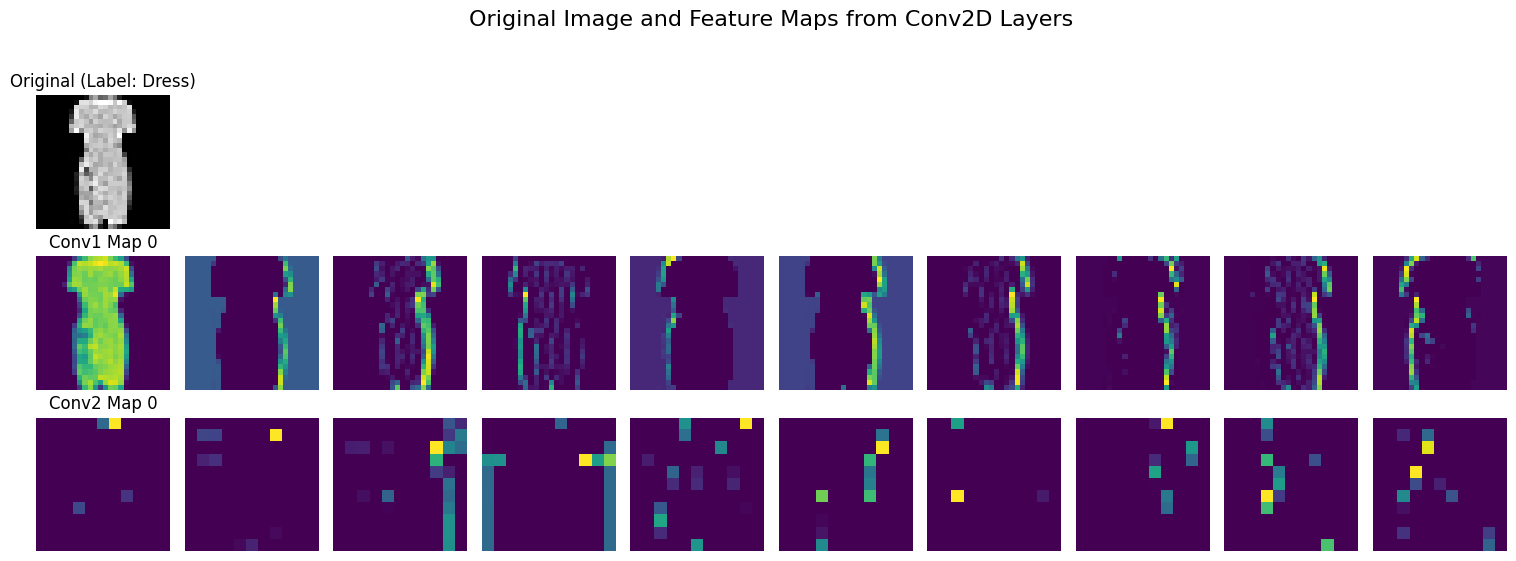

In [ ]:
plt.figure(figsize=(15, 6))

# Display the original image
plt.subplot(len(feature_maps) + 1, 10, 1) # +1 for original image row
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f'Original (Label: {label_mapping[y_test[random_idx]]})')
plt.axis('off')

# Display feature maps for each Conv2D layer
for i, fmap_set in enumerate(feature_maps):
    # Reshape the feature map set to remove the batch dimension (1, height, width, channels)
    fmap_set = fmap_set[0] # Get rid of the batch dimension

    # Display a selection of feature maps for the current layer
    for j in range(min(10, fmap_set.shape[-1])):
        ax = plt.subplot(len(feature_maps) + 1, 10, (i + 1) * 10 + j + 1)
        plt.imshow(fmap_set[:, :, j], cmap='viridis')
        if j == 0:
            ax.set_title(f'Conv{i+1} Map {j}')
        plt.axis('off')

plt.suptitle('Original Image and Feature Maps from Conv2D Layers', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Summary:

### Q&A
The task to extract and visualize feature maps from the `Conv2D` layers of the trained CNN model using a randomly selected image from the test set was successfully completed.

### Data Analysis Key Findings
*   An initial `AttributeError` was encountered when attempting to define the feature map extractor, as `model.input` was not defined. This issue was resolved by explicitly defining a Keras `Input` layer and iteratively constructing the `feature_map_extractor` model by passing the input through the original model's layers.
*   The `feature_map_extractor` model was successfully created and utilized to extract feature maps for a randomly selected image from the test set.
*   Two sets of feature maps were extracted, corresponding to the two `Conv2D` layers in the model, with shapes `(1, 26, 26, 32)` and `(1, 11, 11, 64)` respectively.
*   The original image and a selection of the extracted feature maps from each `Conv2D` layer were successfully visualized, demonstrating the features learned by the model at different processing stages.

### Insights or Next Steps
*   Visualizing feature maps offers valuable insights into the internal workings of a CNN, illustrating how the network learns to detect different patterns and features at various layers.
*   The process could be extended to analyze feature maps for different classes or specific input examples (e.g., correctly classified vs. misclassified images) to gain a deeper understanding of the model's decision boundaries and potential biases.
